In [3]:
from google.colab import files

uploaded = files.upload()

Saving wdbc.data to wdbc.data
Saving wdbc.names to wdbc.names


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [6]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

data.columns = columns

print(data.shape)
display(data.head())

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
data = data.drop("id", axis=1)

data["diagnosis"] = data["diagnosis"].map({
    "B": 0,
    "M": 1
})

X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nClass distribution:")
print(y.value_counts())

Number of samples: 569
Number of features: 30

Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


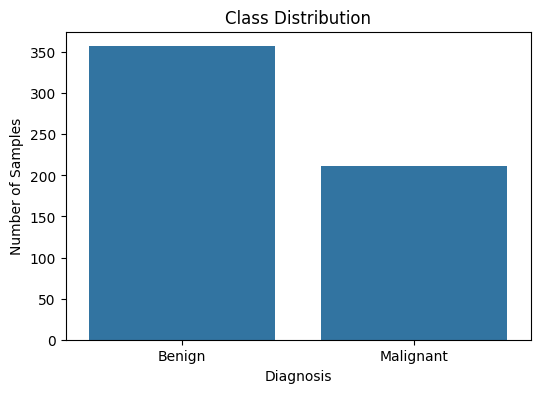

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(x=data["diagnosis"])

plt.xticks([0, 1], ["Benign", "Malignant"])
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

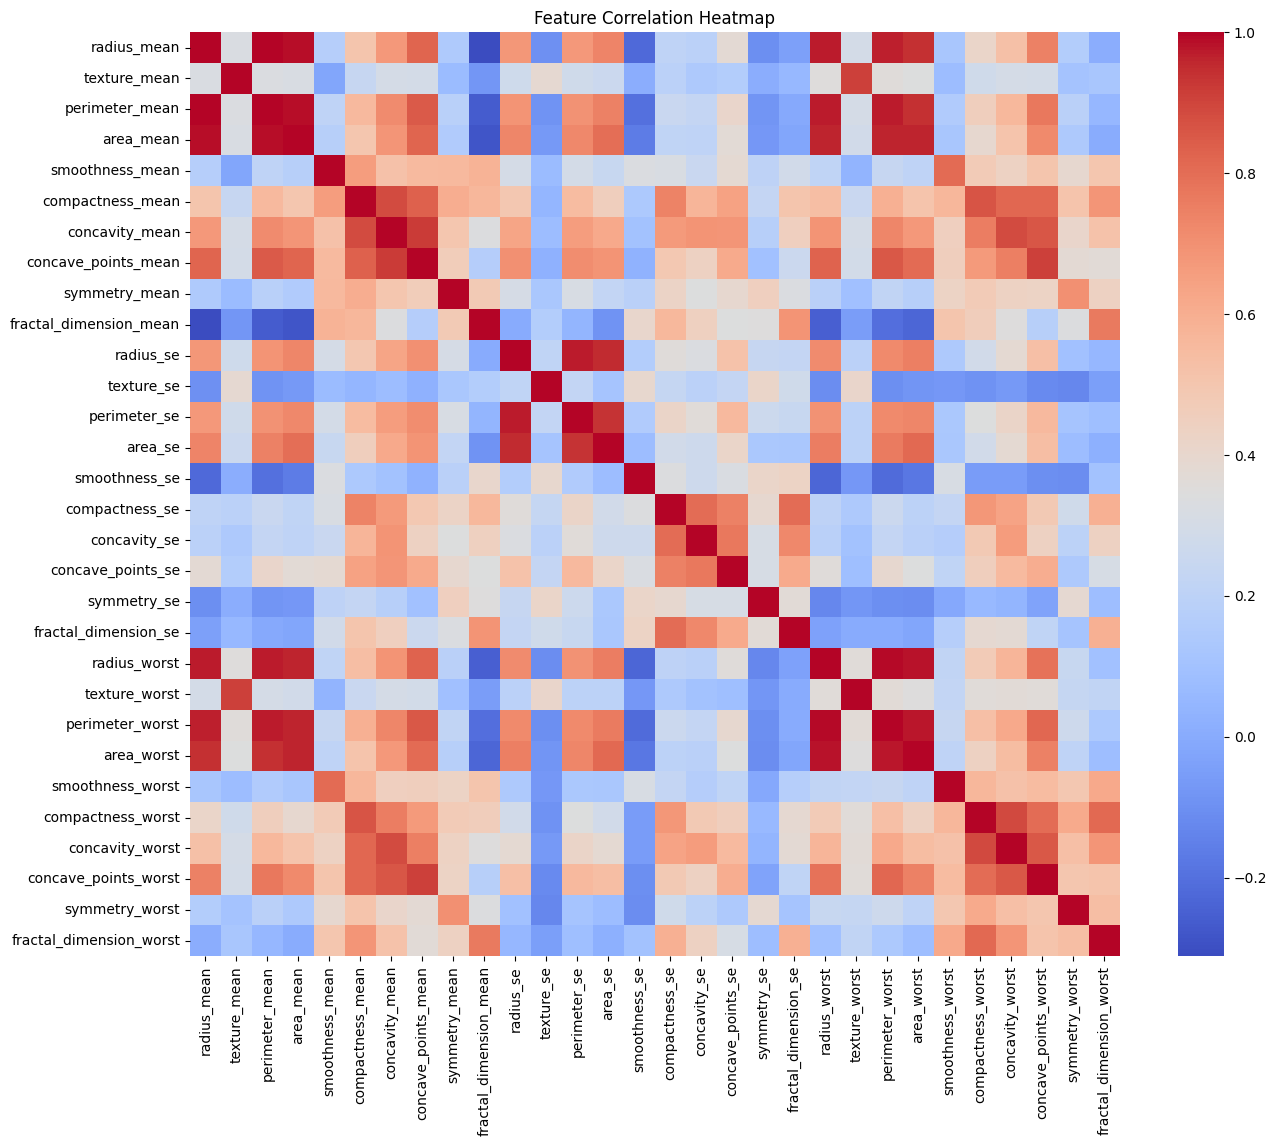

In [9]:
plt.figure(figsize=(15, 12))

sns.heatmap(X.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [11]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9298245614035088


In [12]:
rf = RandomForestClassifier(random_state=42)

In [18]:
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

print("\nBest CV Accuracy:",
      round(dt_grid.best_score_ * 100, 2), "%")

Best parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best CV Accuracy: 93.63 %


In [19]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_table = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score"
    ]
].copy()

dt_table.columns = [
    "Criterion",
    "Max Depth",
    "Min Samples Split",
    "Min Samples Leaf",
    "Avg CV Accuracy (%)"
]

dt_table["Avg CV Accuracy (%)"] = (
    dt_table["Avg CV Accuracy (%)"] * 100
).round(2)

dt_table = dt_table.sort_values(
    "Avg CV Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(dt_table.head(10))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy (%)
0,entropy,5,10,2,93.63
1,entropy,7,10,2,93.41
2,entropy,None,10,2,93.41
3,entropy,7,2,2,92.97
4,gini,7,5,2,92.97
5,entropy,7,5,2,92.97
6,gini,None,5,2,92.97
7,entropy,5,10,1,92.97
8,entropy,None,5,2,92.97
9,entropy,None,2,2,92.97


In [20]:
dt_f1_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_f1_grid.fit(X_train, y_train)

dt_f1_results = pd.DataFrame(dt_f1_grid.cv_results_)

dt_table["Avg CV F1 Score"] = dt_f1_results["mean_test_score"].round(4)

display(dt_table.head(10))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,5,10,2,93.63,0.8884
1,entropy,7,10,2,93.41,0.8874
2,entropy,None,10,2,93.41,0.8871
3,entropy,7,2,2,92.97,0.8871
4,gini,7,5,2,92.97,0.8871
5,entropy,7,5,2,92.97,0.8897
6,gini,None,5,2,92.97,0.8990
7,entropy,5,10,1,92.97,0.8990
8,entropy,None,5,2,92.97,0.8990
9,entropy,None,2,2,92.97,0.8717


In [21]:
dt_f1_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_f1_grid.fit(X_train, y_train)

dt_f1_results = pd.DataFrame(dt_f1_grid.cv_results_)

dt_table["Avg CV F1 Score"] = (
    dt_f1_results["mean_test_score"].round(4)
)

display(dt_table.head(10))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,5,10,2,93.63,0.8884
1,entropy,7,10,2,93.41,0.8874
2,entropy,None,10,2,93.41,0.8871
3,entropy,7,2,2,92.97,0.8871
4,gini,7,5,2,92.97,0.8871
5,entropy,7,5,2,92.97,0.8897
6,gini,None,5,2,92.97,0.8990
7,entropy,5,10,1,92.97,0.8990
8,entropy,None,5,2,92.97,0.8990
9,entropy,None,2,2,92.97,0.8717


In [22]:
best_dt = dt_grid.best_estimator_

best_dt.fit(X_train, y_train)

dt_pred = best_dt.predict(X_test)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nTest Accuracy:",
      round(accuracy_score(y_test, dt_pred) * 100, 2), "%")

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

Test Accuracy: 96.49 %


In [23]:
rf = RandomForestClassifier(random_state=42)

In [24]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

In [25]:
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Accuracy:",
      round(rf_grid.best_score_ * 100, 2), "%")

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}

Best CV Accuracy: 97.14 %


In [26]:
rf_f1_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_f1_grid.fit(X_train, y_train)

rf_results = pd.DataFrame(rf_grid.cv_results_)
rf_f1_results = pd.DataFrame(rf_f1_grid.cv_results_)

In [27]:
rf_table = pd.DataFrame({
    "N Estimators": rf_results["param_n_estimators"],
    "Max Depth": rf_results["param_max_depth"],
    "Max Features": rf_results["param_max_features"],
    "Bootstrap": rf_results["param_bootstrap"],
    "Avg CV Accuracy (%)": rf_results["mean_test_score"] * 100,
    "Avg CV F1 Score": rf_f1_results["mean_test_score"]
})

rf_table["Avg CV Accuracy (%)"] = (
    rf_table["Avg CV Accuracy (%)"].round(2)
)

rf_table["Avg CV F1 Score"] = (
    rf_table["Avg CV F1 Score"].round(4)
)

rf_table = rf_table.sort_values(
    "Avg CV Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(rf_table.head(10))

,N Estimators,Max Depth,Max Features,Bootstrap,Avg CV Accuracy (%),Avg CV F1 Score
0,200,5,sqrt,False,97.14,0.9608
1,200,None,sqrt,False,97.14,0.9615
2,50,None,sqrt,False,96.92,0.9589
3,100,5,sqrt,False,96.92,0.9580
4,50,None,log2,False,96.92,0.9584
5,100,5,sqrt,True,96.70,0.9553
6,100,5,log2,False,96.70,0.9550
7,100,None,log2,False,96.70,0.9556
8,50,5,sqrt,False,96.48,0.9520
9,200,None,log2,True,96.48,0.9526


In [28]:
best_rf = rf_grid.best_estimator_

best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nTest Accuracy:",
      round(accuracy_score(y_test, rf_pred) * 100, 2), "%")

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}

Test Accuracy: 96.49 %


In [29]:
dt_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

table3 = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Fold 1": [
        dt_scores[0] * 100,
        rf_scores[0] * 100
    ],
    "Fold 2": [
        dt_scores[1] * 100,
        rf_scores[1] * 100
    ],
    "Fold 3": [
        dt_scores[2] * 100,
        rf_scores[2] * 100
    ],
    "Fold 4": [
        dt_scores[3] * 100,
        rf_scores[3] * 100
    ],
    "Fold 5": [
        dt_scores[4] * 100,
        rf_scores[4] * 100
    ],
    "Average": [
        dt_scores.mean() * 100,
        rf_scores.mean() * 100
    ]
})

table3.iloc[:, 1:] = table3.iloc[:, 1:].round(2)

display(table3)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,90.11,95.6,91.21,95.6,95.6,93.63
1,Random Forest,95.60,100.0,94.51,96.7,98.9,97.14


In [30]:
dt_pred = best_dt.predict(X_test)
rf_pred = best_rf.predict(X_test)

dt_prob = best_dt.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

In [31]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Decision Tree")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

print("\nRandom Forest")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Decision Tree
Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9048
F1 Score : 0.95

Random Forest
Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9048
F1 Score : 0.95


In [32]:
final_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

final_table.iloc[:, 1:] = final_table.iloc[:, 1:].round(4)

display(final_table)

,Metric,Decision Tree,Random Forest
0,Accuracy,0.9649,0.9649
1,Precision,1.0000,1.0000
2,Recall,0.9048,0.9048
3,F1 Score,0.9500,0.9500


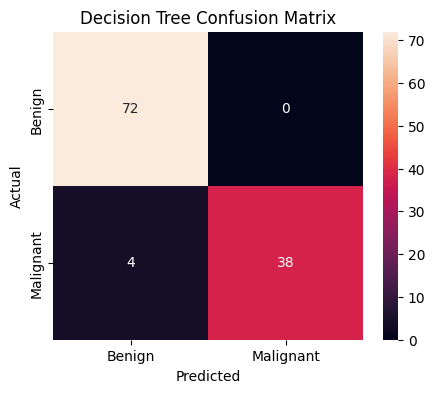

In [33]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

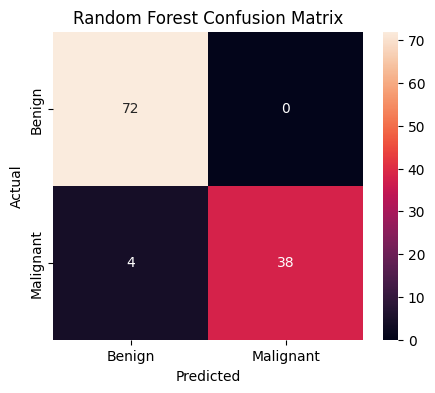

In [34]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

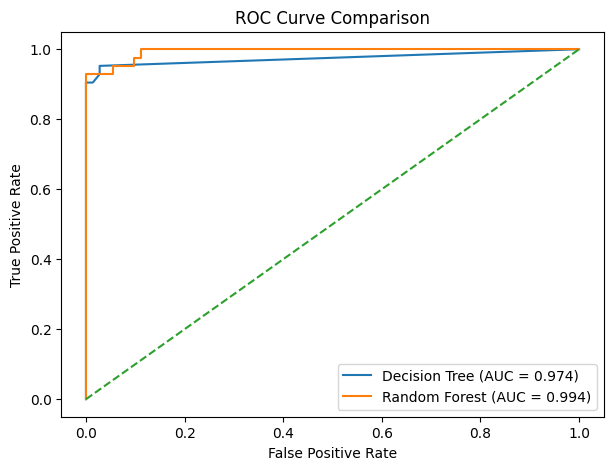

Decision Tree AUC: 0.9744
Random Forest AUC: 0.9937


In [35]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    dt_fpr,
    dt_tpr,
    label="Decision Tree (AUC = %.3f)" % dt_auc
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest (AUC = %.3f)" % rf_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

print("Decision Tree AUC:", round(dt_auc, 4))
print("Random Forest AUC:", round(rf_auc, 4))

In [36]:
dt_train = best_dt.score(X_train, y_train)
dt_test = best_dt.score(X_test, y_test)

rf_train = best_rf.score(X_train, y_train)
rf_test = best_rf.score(X_test, y_test)

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        dt_train,
        rf_train
    ],
    "Testing Accuracy": [
        dt_test,
        rf_test
    ]
})

comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)

display(comparison)

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,0.9758,0.9649
1,Random Forest,0.9912,0.9649


In [37]:
auc_table = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "AUC": [
        dt_auc,
        rf_auc
    ]
})

auc_table["AUC"] = auc_table["AUC"].round(4)

display(auc_table)

,Model,AUC
0,Decision Tree,0.9744
1,Random Forest,0.9937


In [38]:
dt_f1_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_f1_grid.fit(X_train, y_train)

dt_f1_results = pd.DataFrame(dt_f1_grid.cv_results_)

dt_table["Avg CV F1 Score"] = (
    dt_f1_results["mean_test_score"].round(4)
)

display(dt_table.head(10))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,5,10,2,93.63,0.8884
1,entropy,7,10,2,93.41,0.8874
2,entropy,None,10,2,93.41,0.8871
3,entropy,7,2,2,92.97,0.8871
4,gini,7,5,2,92.97,0.8871
5,entropy,7,5,2,92.97,0.8897
6,gini,None,5,2,92.97,0.8990
7,entropy,5,10,1,92.97,0.8990
8,entropy,None,5,2,92.97,0.8990
9,entropy,None,2,2,92.97,0.8717


In [39]:
best_dt = dt_grid.best_estimator_

best_dt.fit(X_train, y_train)

dt_pred = best_dt.predict(X_test)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nTest Accuracy:",
      round(accuracy_score(y_test, dt_pred) * 100, 2), "%")

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

Test Accuracy: 96.49 %
